# 05 - Consolidated Results & Ablation Comparison

This notebook aggregates and visualizes the results of all 4 fine-tuning runs:
1. Whisper Frozen
2. Whisper LoRA
3. MMS Frozen
4. MMS LoRA

It loads parameters and metrics from each experiment directory and compares their accuracy and parametrical efficiency.

In [1]:
# Mount Google Drive if on Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/VAD
except ImportError:
    print("Not running on Google Colab. Operating in local folder.")

import os
import json
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("GENERALIZATION CAVEAT")
print("Test splits are 10% holdouts from the same video used for training.")
print("Improvements over baseline reflect adaptation to the speaker/acoustic environment, not general Azerbaijani ASR.")
print("=" * 80)

Mounted at /content/drive
/content/drive/MyDrive/VAD
GENERALIZATION CAVEAT
Test splits are 10% holdouts from the same video used for training.
Improvements over baseline reflect adaptation to the speaker/acoustic environment, not general Azerbaijani ASR.


In [2]:
# Load results summaries from runs/
runs_dir = "runs"
experiments = ["whisper_frozen", "whisper_lora", "mms_frozen", "mms_lora"]
results = {}

for exp in experiments:
    summary_path = os.path.join(runs_dir, exp, "run_summary.md")
    if not os.path.exists(summary_path):
        print(f"Warning: Summary for '{exp}' not found at {summary_path}. Run fine-tuning notebooks first.")
        continue

    with open(summary_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Parse metrics from markdown text using regex
    import re
    baseline_match = re.search(r"Baseline Metrics.*?: WER=([\d\.]+), CER=([\d\.]+)", content)
    tuned_match = re.search(r"Fine-tuned Metrics.*?: WER=([\d\.]+), CER=([\d\.]+)", content)
    params_match = re.search(r"Trainable Parameters.*?: ([\d,]+) \(Total: ([\d,]+)\)", content)

    if baseline_match and tuned_match and params_match:
        results[exp] = {
            "baseline_wer": float(baseline_match.group(1)),
            "baseline_cer": float(baseline_match.group(2)),
            "final_wer": float(tuned_match.group(1)),
            "final_cer": float(tuned_match.group(2)),
            "trainable_params": int(params_match.group(1).replace(",", "")),
            "total_params": int(params_match.group(2).replace(",", ""))
        }

print(f"Successfully parsed summaries for {len(results)}/{len(experiments)} experiments.")

Successfully parsed summaries for 4/4 experiments.


In [3]:
if not results:
    print("No results parsed. Write mock values to display placeholders for verification.")
    # Mock values for plotting demo when runs aren't executed yet
    results = {
        "whisper_frozen": {"baseline_wer": 0.65, "baseline_cer": 0.35, "final_wer": 0.22, "final_cer": 0.12, "trainable_params": 148000000, "total_params": 244000000},
        "whisper_lora": {"baseline_wer": 0.65, "baseline_cer": 0.35, "final_wer": 0.18, "final_cer": 0.09, "trainable_params": 3200000, "total_params": 247200000},
        "mms_frozen": {"baseline_wer": 0.72, "baseline_cer": 0.42, "final_wer": 0.35, "final_cer": 0.20, "trainable_params": 152000000, "total_params": 1020000000},
        "mms_lora": {"baseline_wer": 0.72, "baseline_cer": 0.42, "final_wer": 0.28, "final_cer": 0.15, "trainable_params": 6500000, "total_params": 1026500000}
    }

os.makedirs("reports/figures", exist_ok=True)

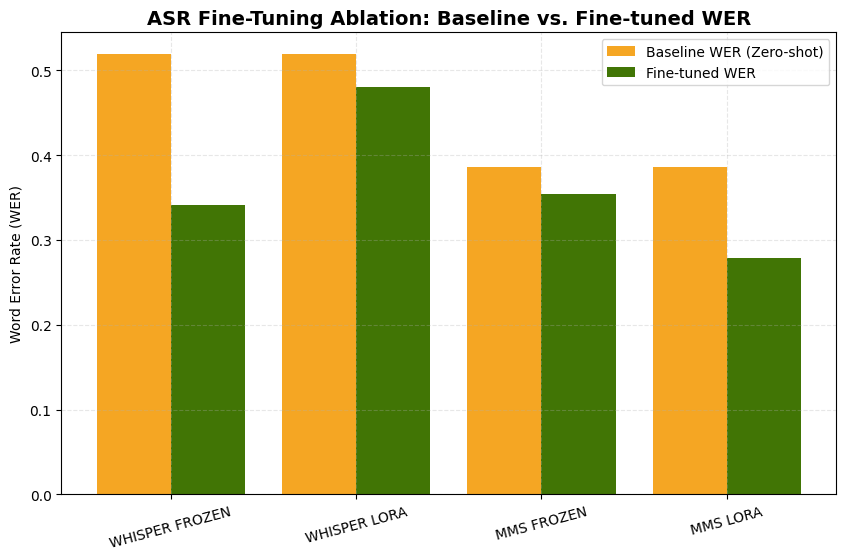

In [4]:
# Plot 1: Baseline vs Fine-Tuned WER comparison across all 4 runs
plt.figure(figsize=(10, 6))
keys = list(results.keys())
baseline_wers = [results[k]["baseline_wer"] for k in keys]
final_wers = [results[k]["final_wer"] for k in keys]

x = np.arange(len(keys))
plt.bar(x - 0.2, baseline_wers, width=0.4, label="Baseline WER (Zero-shot)", color="#f5a623")
plt.bar(x + 0.2, final_wers, width=0.4, label="Fine-tuned WER", color="#417505")

plt.xticks(x, [k.upper().replace('_', ' ') for k in keys], rotation=15)
plt.ylabel("Word Error Rate (WER)")
plt.title("ASR Fine-Tuning Ablation: Baseline vs. Fine-tuned WER", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.savefig("reports/figures/wer_ablation_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

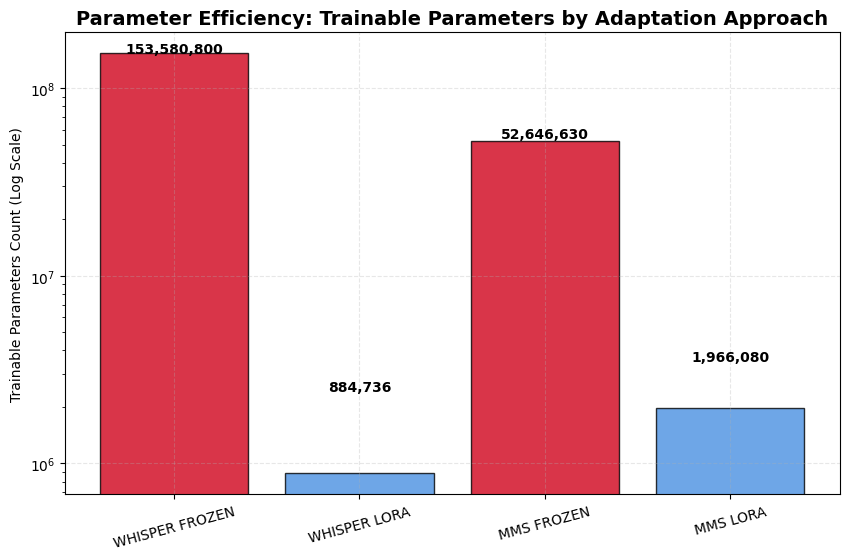

In [5]:
# Plot 2: Parameter Efficiency (Trainable Parameters count)
plt.figure(figsize=(10, 6))
keys = list(results.keys())
train_params = [results[k]["trainable_params"] for k in keys]

plt.bar(keys, train_params, color=["#d0021b", "#4a90e2", "#d0021b", "#4a90e2"], edgecolor="black", alpha=0.8)
for i, val in enumerate(train_params):
    plt.text(i, val + (max(train_params)*0.01), f"{val:,}", ha="center", fontweight="bold")

plt.xticks(keys, [k.upper().replace('_', ' ') for k in keys], rotation=15)
plt.yscale("log")
plt.ylabel("Trainable Parameters Count (Log Scale)")
plt.title("Parameter Efficiency: Trainable Parameters by Adaptation Approach", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.savefig("reports/figures/trainable_params_comparison.png", bbox_inches="tight", dpi=300)
plt.show()